<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c5_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

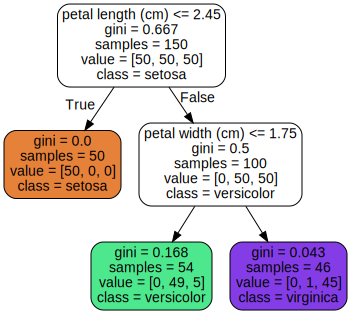

In [8]:
from sklearn.tree import export_graphviz
export_graphviz(
          tree_clf,
          out_file = "iris_tree.dot",
          feature_names = ["petal length (cm)", "petal width (cm)"],
          class_names = iris.target_names,
          rounded=True,
          filled=True
)
from graphviz import Source

Source.from_file("iris_tree.dot")

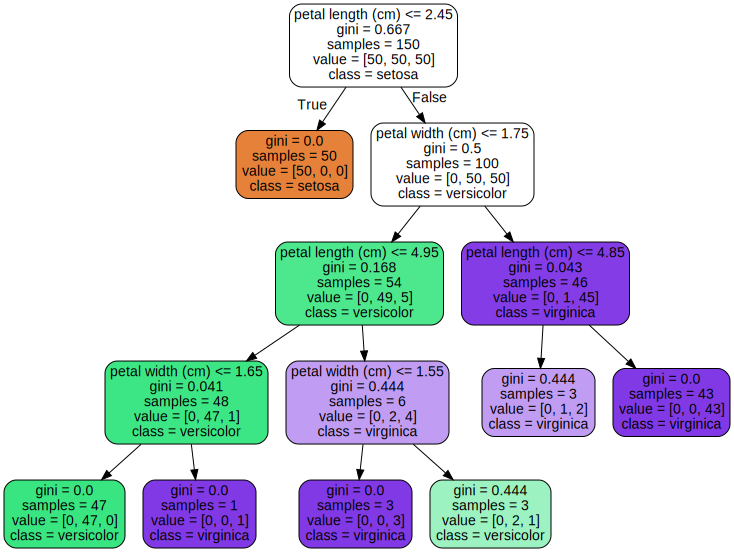

In [9]:
tree_clf2 = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf2.fit(X_iris, y_iris)
export_graphviz(
          tree_clf2,
          out_file = "iris_tree2.dot",
          feature_names = ["petal length (cm)", "petal width (cm)"],
          class_names = iris.target_names,
          rounded=True,
          filled=True
)
Source.from_file("iris_tree2.dot")

In [11]:
from sklearn.metrics import accuracy_score
y_pred = tree_clf.predict(X_iris)
accuracy = accuracy_score(y_iris, y_pred)
y_pred2 = tree_clf2.predict(X_iris)
accuracy2 = accuracy_score(y_iris, y_pred2)

print(f"Accuracy on the training set with depth 2: {accuracy:.4f}")
print(f"Accuracy on the training set with depth 3: {accuracy2:.4f}")

Accuracy on the training set with depth 2: 0.9600
Accuracy on the training set with depth 3: 0.9867


In [13]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng=np.random.default_rng(seed=42)
X_quad = rng.random((200,1))-0.5
y_quad = X_quad**2 + 0.025*rng.standard_normal((200,1))

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)


DecisionTreeRegressor(max_depth=2, random_state=42)

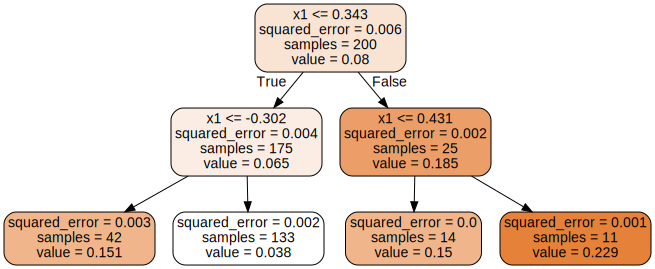

In [15]:

export_graphviz(
          tree_reg,
          out_file = "tree_reg.dot",
          feature_names = ["x1"],
          class_names = iris.target_names,
          rounded=True,
          filled=True
)

Source.from_file("tree_reg.dot")